# Developing Analytic Error Formulas for Tanh Expansion

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from prism.prism_math.activation_coefs import get_alpha_coefs
from prism.prism_math.polynomials import polyval_cpu

## Get the Alpha Coefs

In [2]:
    alpha_coefs, exponents, alpha_coefs_float64 = get_alpha_coefs(
        function_type='tanh',
        big_m=10, v_max=2, dps=64,
        load_file=None, save=False, silent=True)

## Apply an Analytic Formula for the Error

In [3]:
from mpmath import exp, betainc, csch, factorial, im, hyper, re, sin
from mpmath import mp
from mpmath import pi, inf, j
from mpmath import quad

mp.dps = 32

In [4]:
def compute_eta_error_tanh(v_values, big_m=10, v_max=2):

    q = 2*big_m + 3
    tau = (factorial(q)) ** (1/q) / v_max

    eta_error_tanh = np.zeros(v_values.shape)

    for idx in range(0, len(v_values)):
        v = v_values[idx]

        integrand1 = lambda xi: \
            (xi*v)**(2*big_m + 3) * csch(pi/2*xi) \
            * hyper([1], [big_m+2, big_m+5/2], -(xi*v)**2.0/4.0)
        integral1 = quad(integrand1, [0, tau])

        integral2 = 2*np.tanh(v) - (j/pi * betainc(j*v/pi + 1.0/2.0, 0, x1=0, x2=exp(pi*tau)) \
            - j/pi * betainc(1.0/2.0 - j*v/pi, 0, x1=0, x2=exp(pi*tau)))

        eta_error_tanh[idx] = (-1)**(big_m + 1)/factorial(2*big_m+3)*integral1 + re(integral2)

    return eta_error_tanh

In [5]:
v = np.arange(-2.1, 2.1, 0.1)
y = polyval_cpu(alpha_coefs_float64, exponents, v)
y_true = np.tanh(v)

error_numerical = y_true - y
error_analytical = compute_eta_error_tanh(v, big_m=10, v_max=2)

Text(0, 0.5, 'log10(abs(coef))')

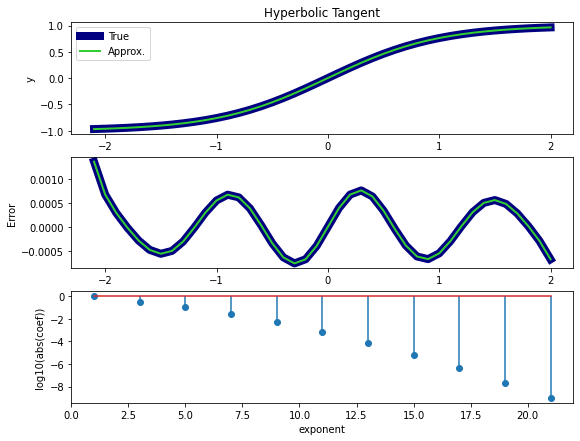

In [6]:
fig, axs = plt.subplots(3, 1, figsize=(9,7))
axs[0].plot(v, y_true, linewidth=8, color='navy')
axs[0].plot(v, y, linewidth=2, color='limegreen')
axs[0].set_xlabel('v')
axs[0].set_ylabel('y')
axs[0].set_title('Hyperbolic Tangent')
axs[0].legend(('True', 'Approx.'))
axs[1].plot(v, error_numerical, linewidth=8, color='navy')
axs[1].plot(v, error_analytical, linewidth=2, color='limegreen')
axs[1].set_xlabel('v')
axs[1].set_ylabel('Error')
axs[2].stem(exponents, np.log10(np.abs(alpha_coefs_float64)))
axs[2].set_xlabel('exponent')
axs[2].set_ylabel('log10(abs(coef))')

In [7]:
exponents

[1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]

## Checking a Beta Function Identity

In [8]:
def ComputeIncBeta1(v_values):

    y = np.zeros(v_values.shape)
    for idx in range(0, len(v_values)):
        v = v_values[idx]
        a = j*v/pi + 1.0/2.0
        b = 0
        result = j/pi * betainc(a, b, x1=0, x2=10000)
        y[idx] = re(result)

    return y

def ComputeIncBeta2(v_values):

    y = np.zeros(v_values.shape)
    for idx in range(0, len(v_values)):
        v = v_values[idx]
        a = 1.0/2.0 - j*v/pi
        b = 0
        result = j/pi * betainc(a, b, x1=0, x2=10000)
        y[idx] = re(result)

    return y

def ComputeIncBeta3(v_values, big_v, big_m):

    y = np.zeros(v_values.shape)
    tau = factorial(2*big_m + 3) ** (1/(2*big_m + 3)) / big_v
    for idx in range(0, len(v_values)):
        v = v_values[idx]
        result = j/pi * betainc(j*v/pi + 1.0/2.0, 0, x1=0, x2=exp(pi*tau))
        y[idx] = re(result)

    return y

def ComputeIncBeta4(v_values, big_v, big_m):

    y = np.zeros(v_values.shape)
    tau = factorial(2*big_m + 3) ** (1/(2*big_m + 3)) / big_v
    for idx in range(0, len(v_values)):
        v = v_values[idx]
        result = j/pi * betainc(1.0/2.0 - j*v/pi, 0, x1=0, x2=exp(pi*tau))
        y[idx] = re(result)

    return y

In [9]:
v = np.arange(-10, 10, 0.1)
y1 = ComputeIncBeta1(v)
y2 = ComputeIncBeta2(v)

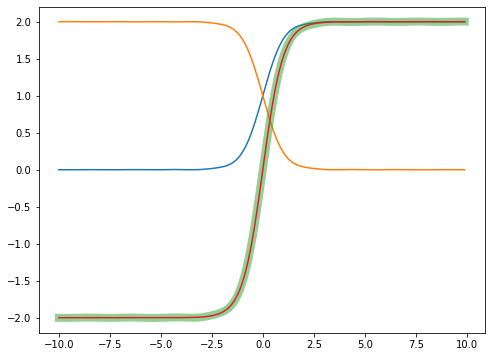

In [10]:
fig, axs = plt.subplots(1, 1, figsize=(8,6))
axs.plot(v, y1)
axs.plot(v, y2)
axs.plot(v, y1 - y2, linewidth=8, alpha=0.5)
axs.plot(v, np.tanh(v) + np.tanh(v))

In [11]:
y3 = ComputeIncBeta3(v, big_v=2, big_m=10)
y4 = ComputeIncBeta4(v, big_v=2, big_m=10)

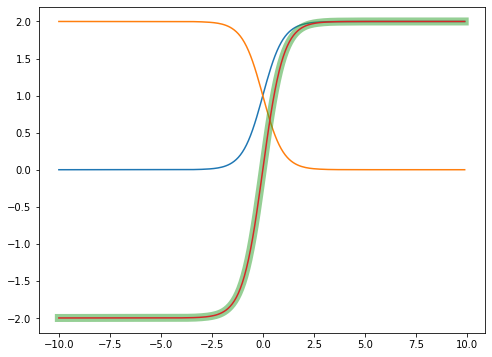

In [12]:
fig, axs = plt.subplots(1, 1, figsize=(8,6))
axs.plot(v, y3)
axs.plot(v, y4)
axs.plot(v, y3 - y4, linewidth=8, alpha=0.5)
axs.plot(v, np.tanh(v) + np.tanh(v))

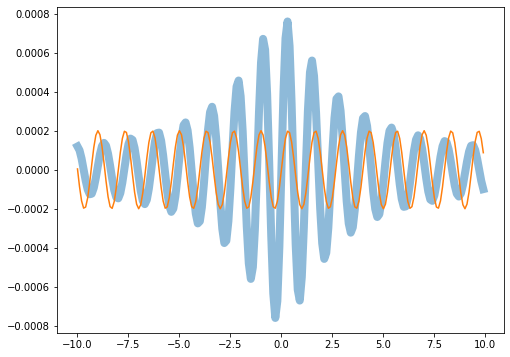

In [13]:
big_m = 10
q = 2*big_m + 3
v_max = 2
tau = (factorial(q)) ** (1/q) / v_max

fig, axs = plt.subplots(1, 1, figsize=(8,6))
#axs.plot(v, (y1 - y2) - (y3 - y4), linewidth=8, alpha=0.5)
axs.plot(v, 2*np.tanh(v) - (y3 - y4), linewidth=8, alpha=0.5)
axs.plot(v, 0.0002*np.sin(float(tau)*v))

In [14]:
tau

mpf('4.7143984340876211364096273144101613')

In [15]:
exponents

[1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]

In [16]:
tau

mpf('4.7143984340876211364096273144101613')